In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data_lake/symbol=BTC-USD/interval=1m')
files = sorted(DATA_DIR.rglob('data.parquet'))

if not files:
    raise FileNotFoundError(
        f'No parquet files found under {DATA_DIR}. '
    )

print(f'Found {len(files)} parquet files')
print(f'First file: {files[0]}')
print(f'Last file: {files[-1]}')


Found 84 parquet files
First file: ..\data_lake\symbol=BTC-USD\interval=1m\year=2026\month=01\day=01\data.parquet
Last file: ..\data_lake\symbol=BTC-USD\interval=1m\year=2026\month=03\day=25\data.parquet


In [2]:
df = pd.concat([pd.read_parquet(file_path) for file_path in files], ignore_index=True)
df = df.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df.head()


,timestamp,datetime,open,high,low,close,volume,symbol,interval,year,month,day
0,1767225600,2026-01-01 00:00:00+00:00,87497.95,87509.86,87456.10,87495.97,9.948370,BTC-USD,1m,2026,1,1
1,1767225660,2026-01-01 00:01:00+00:00,87495.96,87543.98,87494.76,87536.00,2.567234,BTC-USD,1m,2026,1,1
2,1767225720,2026-01-01 00:02:00+00:00,87536.00,87542.00,87463.77,87524.00,10.934966,BTC-USD,1m,2026,1,1
3,1767225780,2026-01-01 00:03:00+00:00,87524.00,87550.00,87523.70,87550.00,6.146775,BTC-USD,1m,2026,1,1
4,1767225840,2026-01-01 00:04:00+00:00,87550.00,87550.00,87549.99,87550.00,2.282604,BTC-USD,1m,2026,1,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120490 entries, 0 to 120489
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   timestamp  120490 non-null  int64              
 1   datetime   120490 non-null  datetime64[us, UTC]
 2   open       120490 non-null  float64            
 3   high       120490 non-null  float64            
 4   low        120490 non-null  float64            
 5   close      120490 non-null  float64            
 6   volume     120490 non-null  float64            
 7   symbol     120490 non-null  str                
 8   interval   120490 non-null  str                
 9   year       120490 non-null  int64              
 10  month      120490 non-null  int64              
 11  day        120490 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(5), int64(4), str(2)
memory usage: 12.1 MB


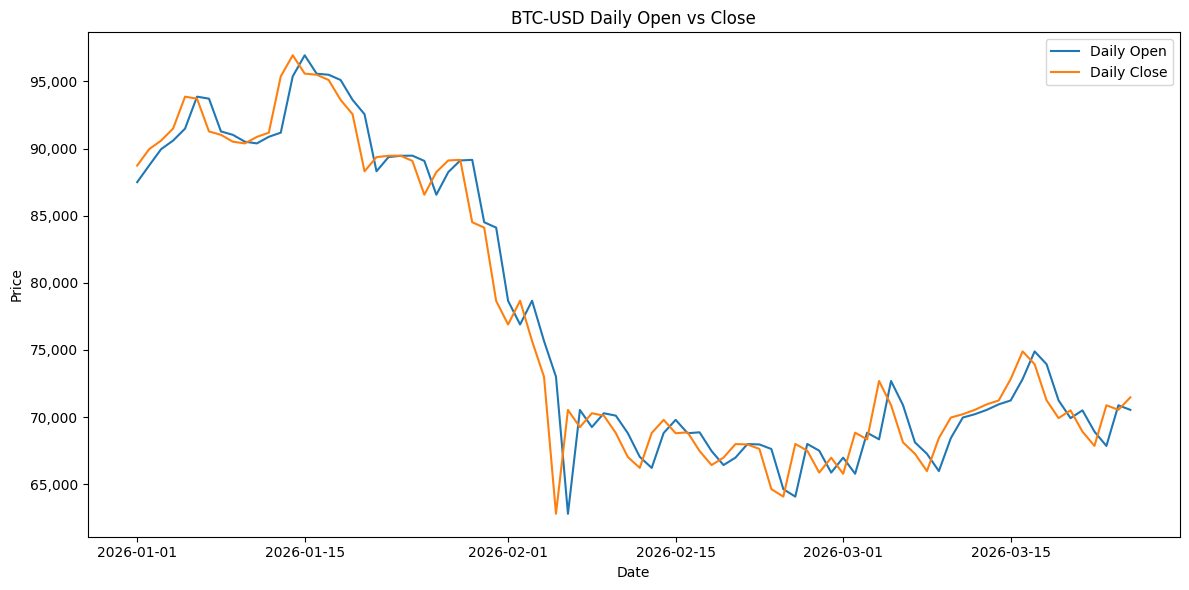

In [4]:
# aggregate to daily open (first) and daily close (last)
daily_df = (
	df.sort_values('datetime')
	  .set_index('datetime')
	  .resample('D')
	  .agg(open=('open', 'first'), close=('close', 'last'))
	  .dropna()
	  .reset_index()
)

# plot daily open vs close
plt.figure(figsize=(12, 6))
plt.title('BTC-USD Daily Open vs Close')
plt.plot(daily_df['datetime'], daily_df['open'], label='Daily Open')
plt.plot(daily_df['datetime'], daily_df['close'], label='Daily Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.legend()
plt.tight_layout()
plt.show()

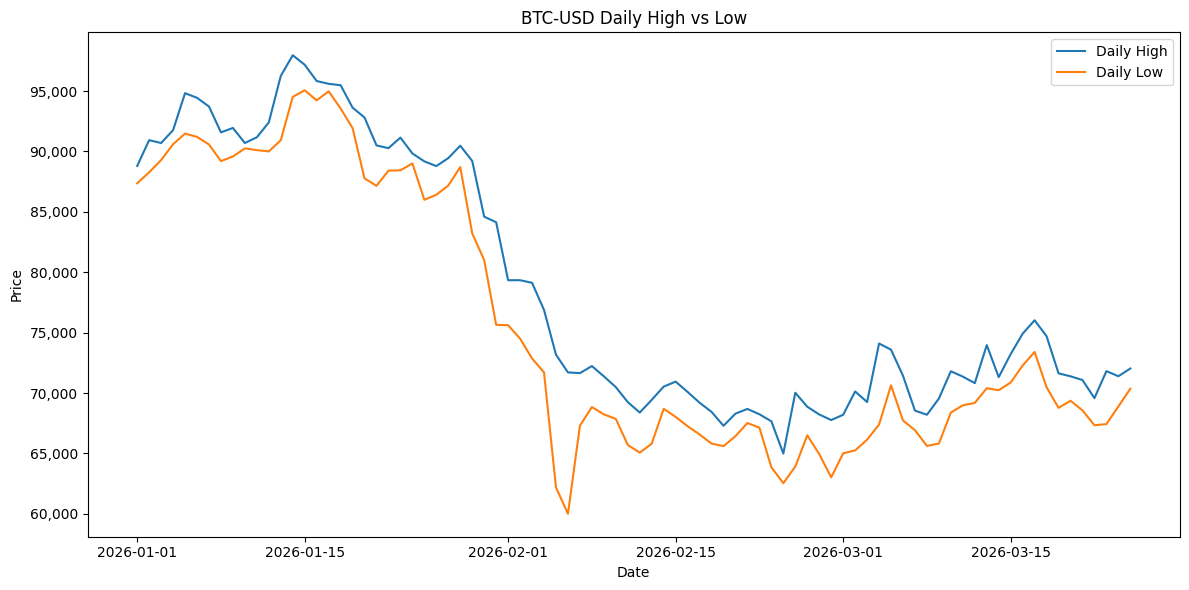

In [5]:
# aggregate to daily High and daily Low
daily_df = (
	df.sort_values('datetime')
	  .set_index('datetime')
	  .resample('D')
	  .agg(high=('high', 'max'), low=('low', 'min'))
	  .dropna()
	  .reset_index()
)

# plot daily high vs low
plt.figure(figsize=(12, 6))
plt.title('BTC-USD Daily High vs Low')
plt.plot(daily_df['datetime'], daily_df['high'], label='Daily High')
plt.plot(daily_df['datetime'], daily_df['low'], label='Daily Low')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.legend()
plt.tight_layout()
plt.show()

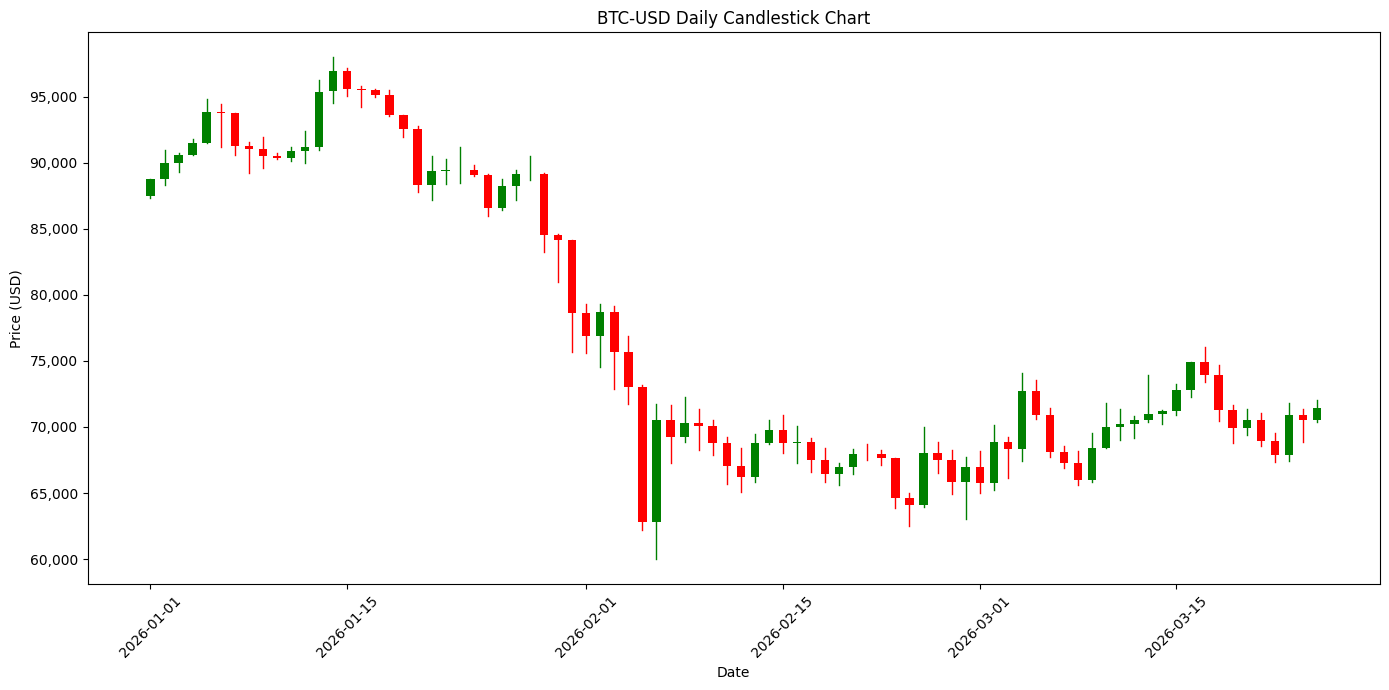

In [6]:
# aggregate to daily OHLC
daily_ohlc = (
    df.sort_values('datetime')
      .set_index('datetime')
      .resample('D')
      .agg(open=('open', 'first'), high=('high', 'max'), low=('low', 'min'), close=('close', 'last'))
      .dropna()
      .reset_index()
)

# plot candlestick chart
fig, ax = plt.subplots(figsize=(14, 7))

for _, row in daily_ohlc.iterrows():
    color = 'green' if row['close'] >= row['open'] else 'red'
    # candle body
    ax.bar(row['datetime'], row['close'] - row['open'], bottom=row['open'], color=color, width=0.6, align='center')
    # wick
    ax.plot([row['datetime'], row['datetime']], [row['low'], row['high']], color=color, linewidth=1)

ax.set_title('BTC-USD Daily Candlestick Chart')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# check missing 1-minute timestamps from 2026-01-01 (UTC) to now (UTC)
start = pd.Timestamp('2026-01-01 00:00:00', tz='UTC')
end = pd.Timestamp.utcnow().floor('min')

# use df['datetime'] (already UTC in earlier cell)
observed = (
    pd.to_datetime(df['datetime'], utc=True)
      .dt.floor('min')
      .dropna()
      .drop_duplicates()
)

expected = pd.date_range(start=start, end=end, freq='1min', tz='UTC')
missing = expected.difference(observed)

print(f"Expected timestamps: {len(expected):,}")
print(f"Observed timestamps: {len(observed):,}")
print(f"Missing timestamps: {len(missing):,}")

if len(missing) > 0:
    print("\nMissing timestamps:")
    print(missing)

    # summarize contiguous missing ranges
    miss_df = pd.DataFrame({'ts': missing})
    grp = (miss_df['ts'].diff() != pd.Timedelta(minutes=1)).cumsum()
    ranges = miss_df.groupby(grp).agg(start=('ts', 'min'), end=('ts', 'max'), n=('ts', 'size'))
    print("\nMissing ranges:")
    display(ranges)
else:
    print("No gaps found.")

Expected timestamps: 120,528
Observed timestamps: 120,490
Missing timestamps: 38

Missing timestamps:
DatetimeIndex(['2026-02-03 17:49:00+00:00', '2026-02-17 19:05:00+00:00',
               '2026-02-17 20:06:00+00:00', '2026-02-17 20:07:00+00:00',
               '2026-02-17 20:08:00+00:00', '2026-02-17 20:09:00+00:00',
               '2026-02-18 01:52:00+00:00', '2026-02-18 01:53:00+00:00',
               '2026-02-19 22:20:00+00:00', '2026-02-19 22:21:00+00:00',
               '2026-02-19 22:22:00+00:00', '2026-02-19 22:23:00+00:00',
               '2026-02-19 22:24:00+00:00', '2026-02-20 23:43:00+00:00',
               '2026-02-22 22:22:00+00:00', '2026-02-22 22:23:00+00:00',
               '2026-02-24 01:07:00+00:00', '2026-02-24 01:08:00+00:00',
               '2026-02-24 03:53:00+00:00', '2026-02-24 03:54:00+00:00',
               '2026-02-24 03:55:00+00:00', '2026-02-24 03:56:00+00:00',
               '2026-02-24 04:13:00+00:00', '2026-02-25 23:23:00+00:00',
               '2026-0

C:\Users\arnav\AppData\Local\Temp\ipykernel_42868\1055036168.py:3: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().floor('min')


,start,end,n
ts,,,
1,2026-02-03 17:49:00+00:00,2026-02-03 17:49:00+00:00,1
2,2026-02-17 19:05:00+00:00,2026-02-17 19:05:00+00:00,1
3,2026-02-17 20:06:00+00:00,2026-02-17 20:09:00+00:00,4
4,2026-02-18 01:52:00+00:00,2026-02-18 01:53:00+00:00,2
5,2026-02-19 22:20:00+00:00,2026-02-19 22:24:00+00:00,5
6,2026-02-20 23:43:00+00:00,2026-02-20 23:43:00+00:00,1
7,2026-02-22 22:22:00+00:00,2026-02-22 22:23:00+00:00,2
8,2026-02-24 01:07:00+00:00,2026-02-24 01:08:00+00:00,2
9,2026-02-24 03:53:00+00:00,2026-02-24 03:56:00+00:00,4
